# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Generate Pseudo-Absence Data
Absence data must be generated for these classifiers, and different quantities must be generated for types of classifiers, based on Barbet-Massin et al., 2012.

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [1]:
import os
# os.mkdir("inputs", ex)
# os.mkdir("outputs")
import subprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from pygam import LogisticGAM, s, f
from sklearn.tree import DecisionTreeClassifier
# out of all the glms, we choose the poisson - it does not have negative values, and varying variance???
# also we are looking for a scale of values up to 1000...
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pyimpute import impute
from sklearn import model_selection
from elapid import MaxentModel

import warnings
warnings.filterwarnings('ignore')

In [2]:
files_list = ["nst_pest_sightings\\bean_leaf_beetle_0003221-260623161305970\\0003221-260623161305970.csv", 
              "nst_pest_sightings\\bird_cherry_aphid_0003207-260623161305970\\0003207-260623161305970.csv",
              "nst_pest_sightings\\black_cutworm_0003212-260623161305970\\0003212-260623161305970.csv",
            #   "nst_pest_sightings\\corn_leaf_aphid_0003215-260623161305970\\0003215-260623161305970.csv",
              "nst_pest_sightings\\differential_grasshopper_observations-752834.csv\\observations-752834.csv",
            #   "nst_pest_sightings\\european_corn_borer0003385-260623161305970\\0003385-260623161305970.csv",
              "nst_pest_sightings\\green_stink_0005409-260623161305970\\0005409-260623161305970.csv",
            #   "nst_pest_sightings\\hessian_fly_0003394-260623161305970\\0003394-260623161305970.csv",
              "nst_pest_sightings\\japanese_beetle_0003383-260623161305970\\0003383-260623161305970.csv",
              "nst_pest_sightings\\northern_corn_rootworm_0003360-260623161305970\\0003360-260623161305970.csv",
            #   "nst_pest_sightings\\reg_legged_grasshopperobservations-752840.csv\\observations-752840.csv",
              "nst_pest_sightings\\seedcorn_maggot_0003200-260623161305970\\0001692-260720095953322.csv",
              "nst_pest_sightings\\southern_green_stink_0003348-260623161305970\\0003348-260623161305970.csv",
              "nst_pest_sightings\\three_cornered_alfalfa_0003390-260623161305970\\0003390-260623161305970.csv",
              "nst_pest_sightings\\true_armyworm0032387-260623161305970\\0032387-260623161305970.csv",
            #   "nst_pest_sightings\\two_striped_grasshopper_observations-752841.csv\\observations-752841.csv",
              "nst_pest_sightings\\western_corn_rootworm_0003372-260623161305970\\0003372-260623161305970.csv"
              ]

for file in files_list:
    with open(file, mode='r', encoding='utf-8') as file:
        row_count = sum(1 for line in file)

    print(f"{file}, Total lines: {row_count}")

<_io.TextIOWrapper name='nst_pest_sightings\\bean_leaf_beetle_0003221-260623161305970\\0003221-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 849
<_io.TextIOWrapper name='nst_pest_sightings\\bird_cherry_aphid_0003207-260623161305970\\0003207-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 882
<_io.TextIOWrapper name='nst_pest_sightings\\black_cutworm_0003212-260623161305970\\0003212-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 2273
<_io.TextIOWrapper name='nst_pest_sightings\\differential_grasshopper_observations-752834.csv\\observations-752834.csv' mode='r' encoding='utf-8'>, Total lines: 2125
<_io.TextIOWrapper name='nst_pest_sightings\\green_stink_0005409-260623161305970\\0005409-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 7806
<_io.TextIOWrapper name='nst_pest_sightings\\japanese_beetle_0003383-260623161305970\\0003383-260623161305970.csv' mode='r' encoding='utf-8'>, Total lines: 556
<_io.TextIOWrapper name='nst_pest_s

Run the subprocess, R code to generate pseudo absences. Will be customized depending on the models

In [3]:
command_ncr = ["C:\\Program Files\\R\\R-4.4.1\\bin\\Rscript.exe",'pseudo_absence.R', 
           files_list[6], "seedcorn"]

command_tsg = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', "2", "northerncorn"]
try:
    subprocess.run(command_ncr, capture_output=True, 
        text=True, check = True)
except subprocess.CalledProcessError as e:
    print(f"R Script failed with exit code {e.returncode}")
    print("Error Message:\n", e.stderr)

### Converting shapefiles (.shp) to geopandas dataframe

In [4]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf_mid = gpd.GeoDataFrame.from_file('data/' + command_ncr[3] + '/mid.shp')
ncr_gdf_high = gpd.GeoDataFrame.from_file('data/' + command_ncr[3] + '/high.shp')



Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [5]:
print("Number of duplicates: ", ncr_gdf_mid.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf_mid['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf_mid.crs))
print("{} observations with {} columns".format(*ncr_gdf_mid.shape))

print("Number of duplicates: ", ncr_gdf_high.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf_high['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf_high.crs))
print("{} observations with {} columns".format(*ncr_gdf_high.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
1999 observations with 2 columns
Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
10999 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

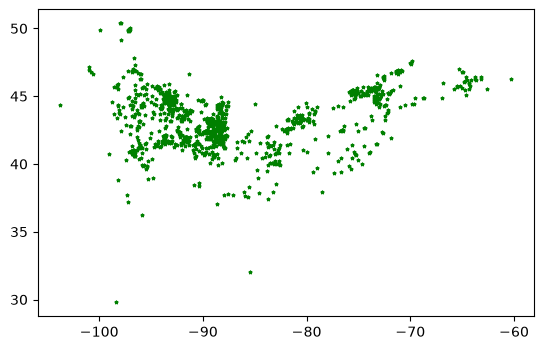

In [6]:
ncr_gdf_mid[ncr_gdf_mid.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

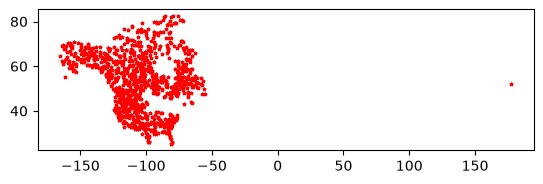

In [7]:
ncr_gdf_mid[ncr_gdf_mid.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [8]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = ["chelsa_clim/CHELSA_bio02_1981-2010_V.2.1.tif", 
             "chelsa_clim/CHELSA_bio04_1981-2010_V.2.1.tif", 
             "chelsa_clim/CHELSA_bio06_1981-2010_V.2.1.tif",
             "chelsa_clim/CHELSA_bio14_1981-2010_V.2.1.tif",
             "chelsa_clim/CHELSA_bio15_1981-2010_V.2.1.tif",
             "chelsa_clim/CHELSA_bio19_1981-2010_V.2.1.tif",
             "chelsa_clim/CHELSA_fgd_1981-2010_V.2.1.tif",
             "chelsa_clim/CHELSA_scd_1981-2010_V.2.1.tif"]
# sorted(glob.glob(
#         'chelsa_clim/CHELSA_bio*.tif'))
    # 'worldclim/wc2.1_2.5m_bio_*.tif'))

# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(ras_feats), ' raster features.')
print(ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6


There are  8  raster features.
['chelsa_clim/CHELSA_bio02_1981-2010_V.2.1.tif', 'chelsa_clim/CHELSA_bio04_1981-2010_V.2.1.tif', 'chelsa_clim/CHELSA_bio06_1981-2010_V.2.1.tif', 'chelsa_clim/CHELSA_bio14_1981-2010_V.2.1.tif', 'chelsa_clim/CHELSA_bio15_1981-2010_V.2.1.tif', 'chelsa_clim/CHELSA_bio19_1981-2010_V.2.1.tif', 'chelsa_clim/CHELSA_fgd_1981-2010_V.2.1.tif', 'chelsa_clim/CHELSA_scd_1981-2010_V.2.1.tif']


In [9]:
import rasterio

with rasterio.open(ras_feats[0]) as src:
    raster_crs = src.crs

ncr_gdf_mid = ncr_gdf_mid.to_crs(raster_crs)
ncr_gdf_high = ncr_gdf_high.to_crs(raster_crs)

ncr_gdf_low = []
for i in range(1,11):
    ncr_gdf_low.append(gpd.GeoDataFrame.from_file('data/' + command_ncr[3] + '/low/'+ str(i) + '.shp').to_crs(raster_crs))

 
print(ncr_gdf_mid.crs)


GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [10]:
ncr_gdf_mid.sample(5)

,CLASS,geometry
1709,0.0,POINT (-129.03553 61.17499)
900,1.0,POINT (-89.46293 41.91091)
962,0.0,POINT (-113.96404 38.27226)
1298,0.0,POINT (-81.01943 38.31884)
606,0.0,POINT (-90.83785 30.20562)


Generate raster maps of suitability. Also separate test sets from the rest for cross validation

In [11]:
from pyimpute import load_training_vector
from pyimpute import load_targets
import numpy as np
import pandas as pd

train_xs_mid, train_ys_mid = load_training_vector(ncr_gdf_mid, ras_feats, response_field='CLASS')

x_df_mid = pd.DataFrame(train_xs_mid)
x_df_mid.columns = ['bio2', 'bio4', 'bio6', 'bio14', 'bio15', 'bio19', 'fgd', 'scd']
x_df_mid = x_df_mid.apply(pd.to_numeric, errors="coerce")
x_df_mid = x_df_mid.replace([np.inf, -np.inf], np.nan)

y_ser_mid = pd.Series(train_ys_mid)

mask_mid = x_df_mid.notna().all(axis=1) & y_ser_mid.notna()

# Apply mask_mid to both X and y
train_xs_mid_clean = x_df_mid.loc[mask_mid].to_numpy(dtype=float)
train_ys_mid_clean = y_ser_mid.loc[mask_mid].to_numpy()

print("Original samples:", len(train_xs_mid))
print("Clean samples:", len(train_xs_mid_clean))
print("Dropped samples:", len(train_xs_mid) - len(train_xs_mid_clean))


train_x_mid, test_x_mid, train_y_mid, test_y_mid = model_selection.train_test_split(train_xs_mid_clean, train_ys_mid_clean, test_size=0.25, random_state=42, stratify=train_ys_mid_clean)
# train_xs_mid.shape, train_ys_mid.shape
train_x_mid.shape, test_x_mid.shape, train_y_mid.shape, test_y_mid.shape

Original samples: 1999
Clean samples: 1999
Dropped samples: 0


((1499, 8), (500, 8), (1499,), (500,))

In [12]:
x_df_mid.sample(5)

,bio2,bio4,bio6,bio14,bio15,bio19,fgd,scd
1782,127.0,10010.0,2646.0,111.0,576.0,343.0,80.0,115.0
404,109.0,9141.0,2636.0,130.0,636.0,445.0,101.0,144.0
323,46.0,9876.0,2670.0,703.0,119.0,2224.0,118.0,132.0
1902,92.0,13375.0,2469.0,198.0,516.0,696.0,153.0,225.0
1638,103.0,10617.0,2629.0,189.0,522.0,629.0,90.0,123.0


           bio2      bio4      bio6     bio14     bio15     bio19       fgd  \
bio2   1.000000 -0.404723  0.594721 -0.190899 -0.024878 -0.109489 -0.374341   
bio4  -0.404723  1.000000 -0.887554 -0.472771  0.405616 -0.550885  0.527773   
bio6   0.594721 -0.887554  1.000000  0.339082 -0.404582  0.333072 -0.626284   
bio14 -0.190899 -0.472771  0.339082  1.000000 -0.746967  0.756250 -0.115883   
bio15 -0.024878  0.405616 -0.404582 -0.746967  1.000000 -0.348039  0.180013   
bio19 -0.109489 -0.550885  0.333072  0.756250 -0.348039  1.000000 -0.038530   
fgd   -0.374341  0.527773 -0.626284 -0.115883  0.180013 -0.038530  1.000000   
scd   -0.674171  0.651970 -0.896422 -0.134128  0.310510 -0.082528  0.626797   

            scd  
bio2  -0.674171  
bio4   0.651970  
bio6  -0.896422  
bio14 -0.134128  
bio15  0.310510  
bio19 -0.082528  
fgd    0.626797  
scd    1.000000  


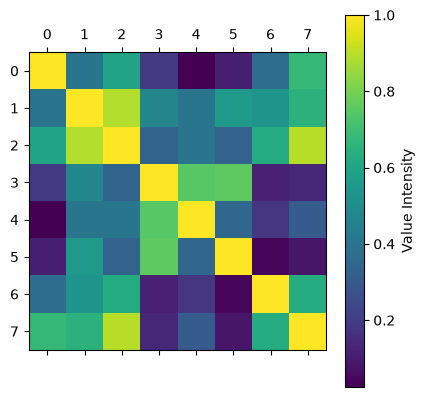

In [13]:
import matplotlib.pyplot as plt
corr = x_df_mid.corr(method="pearson")
print(corr)

corr = np.abs(corr)
plt.matshow(corr)
plt.colorbar(label='Value Intensity')
plt.show()

In [14]:
print(train_x_mid)

[[   71.  6696.  2651. ...  8840.   215.   272.]
 [  117.  9526.  2598. ...   386.   117.   172.]
 [   78.  9811.  2642. ...  1334.   102.   128.]
 ...
 [   97. 10388.  2636. ...   931.    87.   115.]
 [  101. 10998.  2606. ...   505.    98.   140.]
 [   73.  9845.  2612. ...  2169.   125.   155.]]


In [15]:
train_xs_high, train_ys_high = load_training_vector(ncr_gdf_high, ras_feats, response_field='CLASS')

x_df_high = pd.DataFrame(train_xs_high)
x_df_high = x_df_high.apply(pd.to_numeric, errors="coerce")
x_df_high = x_df_high.replace([np.inf, -np.inf], np.nan)

y_ser_high = pd.Series(train_ys_high)

mask_high = x_df_high.notna().all(axis=1) & y_ser_high.notna()

# Apply mask_mid to both X and y
train_xs_high_clean = x_df_high.loc[mask_high].to_numpy(dtype=float)
train_ys_high_clean = y_ser_high.loc[mask_high].to_numpy()

print("Original samples:", len(train_xs_high))
print("Clean samples:", len(train_xs_high_clean))
print("Dropped samples:", len(train_xs_high) - len(train_xs_high_clean))


train_x_high, test_x_high, train_y_high, test_y_high = model_selection.train_test_split(train_xs_high_clean, train_ys_high_clean, test_size=0.25, random_state=42, stratify=train_ys_high_clean)
# train_xs_mid.shape, train_ys_mid.shape
train_x_high.shape, test_x_high.shape, train_y_high.shape, test_y_high.shape

Original samples: 10999
Clean samples: 10999
Dropped samples: 0


((8249, 8), (2750, 8), (8249,), (2750,))

Classifier implementation

In [16]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

sample_weights_mid = compute_sample_weight(class_weight='balanced', y=train_y_mid)
sample_weights_high = compute_sample_weight(class_weight='balanced', y=train_y_high)
k = 10
kf = model_selection.KFold(n_splits=k, shuffle=True, random_state=42)

def make_model_dict(name, model, model_class):
    return {
        "name": name,
        "model": model,
        "threshold": -1,
        "auc": -1,
        "maxsss": -1,
        "frozen model": None,
        "class": model_class
    }

rf = make_model_dict("random forest", RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1), "tree")

lda = make_model_dict("lda", LinearDiscriminantAnalysis(), "linear")

dtc = make_model_dict("decision tree", DecisionTreeClassifier(max_depth=6, min_samples_split=5, random_state=42), "tree")

lr = make_model_dict("log res glm", LogisticRegression(max_iter = 1000), "linear")

lr1 = make_model_dict("log res big", LogisticRegression(max_iter=5000), "linear")

xgb = make_model_dict("xg boost", XGBClassifier(), "tree")

mars_model = make_pipeline(SplineTransformer(degree=1, n_knots=10, include_bias=False), LogisticRegression())
mars = make_model_dict("mars", mars_model, "other")

me = make_model_dict("maxent", MaxentModel(), "other")

gam = make_model_dict("log gam", LogisticGAM(s(0) + s(1) + s(2), lam = 10), "linear")

models = [rf, lda, dtc, lr, lr1, xgb, mars, me]

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.inspection import permutation_importance

cand_thresholds = np.linspace(0, 1, 1001)

train_x_models, ensemble_val_x, train_y_models, ensemble_val_y = model_selection.train_test_split(train_x_mid, train_y_mid, test_size=0.2, random_state=42, stratify=train_y_mid)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model in models:
# train the model (cross validate)
    thresholds = []
    msss_scores = []
    print(model["name"])
    try:
        cv_score = model_selection.cross_val_score(model["model"], train_x_models, train_y_models, cv=skf)
        print("Cross validation score:", np.mean(cv_score))
    except AttributeError as e:
        print("cross validation score not available for this model.")

    for train_id, val_id in skf.split(train_x_models, train_y_models):
        x_train = train_x_models[train_id]
        x_val = train_x_models[val_id]
        y_train = train_y_models[train_id]
        y_val = train_y_models[val_id]

        model["model"].fit(x_train, y_train)
# calculate probabilities with val data
        try:
            val_prob = model["model"].predict_proba(x_val)[:, 1]
        except IndexError as e:
            val_prob = model["model"].predict_proba(x_val)
# scores = model_selection.cross_val_score(model["model"], train_x_mid, train_y_mid, cv=kf, scoring="")
# calculate threshold

        best_threshold = 0
        best_sum = -1
        # best_sensit = -1
        # best_specif = -1

        for threshold in cand_thresholds:
            val_pred = (val_prob >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_val, val_pred, labels=[0, 1]).ravel()

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

            sens_spec_sum = sensitivity + specificity

            if sens_spec_sum > best_sum:
                best_sum = sens_spec_sum
                best_threshold = threshold
            # best_sensitivity = sensitivity
            # best_specificity = specificity
    thresholds.append(best_threshold)
    msss_scores.append(best_sum)
    # model["threshold"] = best_threshold
    model["threshold"] = np.mean(thresholds)
    model["maxsss"] = np.mean(msss_scores)
    
    print("Best threshold:", model["threshold"])
    print("Max sensitivity + specificity:", model["maxsss"])
    # print("Sensitivity:", best_sensitivity)
    # print("Specificity:", best_specificity)
    print("Youden J:", model["maxsss"] - 1)
# retrain the model with all training data available
    model["model"].fit(train_x_models, train_y_models)
    model["frozen model"] = FrozenEstimator(model["model"])
    print("model frozen")

    try:
        test_prob = model["model"].predict_proba(test_x_mid)[:, 1]
    except IndexError as e:
        test_prob = model["model"].predict_proba(test_x_mid)

    test_pred = (test_prob >= model["threshold"]).astype(int)

# find auc at the threshold
    auc_score = roc_auc_score(test_y_mid, test_pred)
    model["auc"] = auc_score
    print("AUC score: ", auc_score)
    try:
        results = permutation_importance(model["model"], test_x_mid, test_y_mid, scoring='roc_auc')
        for i, v in enumerate(results.importances_mean):
            print(f'Feature: {i}, Score: {v:.5f}')
    except AttributeError as e:
        "permutation importance not available for this model"
        # plt.bar([x for x in range(len(results.importances_mean))], results.importances_mean)
        # plt.show()

    if model["class"] == "tree":
        importances = model["model"].feature_importances_
        feature_importance = pd.DataFrame({'Feature': x_df_mid.columns, 'Importance': importances})
        print(feature_importance.sort_values(by='Importance', ascending=False))
    elif model["class"] == "linear":
        importances = model["model"].coef_[0]
        feature_importance = pd.DataFrame({'Feature': x_df_mid.columns, 'Importance': importances})
        print(feature_importance.sort_values(by='Importance', ascending=False))
    

random forest
Cross validation score: 0.97331589958159
Best threshold: 0.211
Max sensitivity + specificity: 1.9833333333333334
Youden J: 0.9833333333333334
model frozen
AUC score:  0.9540000000000001
Feature: 0, Score: 0.02453
Feature: 1, Score: 0.01519
Feature: 2, Score: 0.00239
Feature: 3, Score: 0.00450
Feature: 4, Score: 0.00148
Feature: 5, Score: 0.00028
Feature: 6, Score: 0.00159
Feature: 7, Score: 0.06863
  Feature  Importance
7     scd    0.241543
2    bio6    0.194413
1    bio4    0.164800
6     fgd    0.135621
0    bio2    0.134622
3   bio14    0.062563
4   bio15    0.042576
5   bio19    0.023861
lda
Cross validation score: 0.8665725244072524
Best threshold: 0.41100000000000003
Max sensitivity + specificity: 1.7999299719887956
Youden J: 0.7999299719887956
model frozen
AUC score:  0.824
Feature: 0, Score: 0.02983
Feature: 1, Score: 0.21748
Feature: 2, Score: 0.45010
Feature: 3, Score: 0.00521
Feature: 4, Score: 0.12935
Feature: 5, Score: 0.02499
Feature: 6, Score: -0.00679
Fea

In [18]:
# ensemble models: find the indices of the dictionary models with the highest auc and tss scores? 
# find the highest auc and tss amongst different groups of classifiers: regressors, 
import heapq

auc_scores = []
tss_scores = []

for model in models:
    auc_scores.append(model["auc"])
    tss_scores.append(model["maxsss"] - 1)

largest_auc = heapq.nlargest(3, range(len(auc_scores)), key=auc_scores.__getitem__)
print(largest_auc)



[5, 7, 0]


Loading future predictions

In [19]:
# from pylab import plt
# future_stacks = ["worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040.tif", "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp245_2021-2040.tif",
#                 "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp370_2021-2040.tif", "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp585_2021-2040.tif"]

# future_40_stacks = ["worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2041-2060.tif", 
#                     # "worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp245_2041-2060.tif", 
#                     "worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp370_2041-2060.tif",
#                     "worldclim\\future40\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp585_2041-2060.tif"]

# # chelsa_scd_40_stacks = ["chelsa_clim\\future\\scd\\CHELSA_mpi-esm1-2-hr_ssp370_scd_2041-2070_V.2.1.tif",
# #                     "chelsa_clim\\future\\scd\\CHELSA_mpi-esm1-2-hr_ssp585_fgd_2041-2070_V.2.1.tif",
# #                     "chelsa_clim\\future\\scd\\CHELSA_mpi-esm1-2-hr_ssp585_scd_2041-2070_V.2.1.tif"
# #                     ]

# # chelsa_fgd_40_stacks = ["chelsa_clim\\future\\fgd\\CHELSA_mpi-esm1-2-hr_ssp126_fgd_2041-2070_V.2.1.tif",
# #                         "chelsa_clim\\future\\fgd\\CHELSA_mpi-esm1-2-hr_ssp126_scd_2041-2070_V.2.1.tif",
# #                         "chelsa_clim\\future\\fgd\\CHELSA_mpi-esm1-2-hr_ssp370_fgd_2041-2070_V.2.1.tif"]
# out_dir = "future_split_bands"

# from rasterio.windows import from_bounds


# training_feature_names = [
#     "bio2",
#     "bio4",
#     # "bio5",
#     "bio6",
#     # "bio13",
#     "bio14",
#     "bio15",
#     "bio19"
# ]

# future_band_map = {
#     # "bio13": 13,
#     "bio19": 19,
#     "bio14": 14,
#     "bio15": 15,
#     "bio2": 2,
#     "bio4": 4,
#     # "bio5": 5,
#     "bio6": 6
# }
# min_lon = -170
# max_lon = -52
# min_lat = 24
# max_lat = 83.5

# future_ras_feats = []

# for index, stack in enumerate(future_40_stacks):
#     # os.mkdir(f"{out_dir}_{index}")
#     with rasterio.open(stack) as src:
#         # print("Band count:", src.count)
#         # print("CRS:", src.crs)
#         # print("Shape:", src.shape)
#         # print("Bounds:", src.bounds)
#         # print("Descriptions:", src.descriptions)
#         # print("Indexes:", src.indexes)
# # with rasterio.open(future_stack) as src:
#         window = from_bounds(
#                 min_lon,
#                 min_lat,
#                 max_lon,
#                 max_lat,
#                 transform=src.transform
#         ).round_offsets().round_lengths()

#         data = src.read(1, window=window)

#         new_transform = src.window_transform(window)

#         profile = src.profile.copy()
#         profile.update({
#             "height": data.shape[0],
#             "width": data.shape[1],
#             "transform": new_transform,
#             "count": 1
#         })
        
#         temp_future_ras_feats = []
#         for feature_name in training_feature_names:
            
#             band_index = future_band_map[feature_name]

#             band = src.read(band_index, window=window)

#             out_path = os.path.join(f"{out_dir}_{index}", f"future_{feature_name}.tif")
#             with rasterio.open(out_path, "w", **profile) as dst:
#                 dst.write(band, 1)
#                 dst.set_band_description(1, feature_name)

#             temp_future_ras_feats.append(out_path)
#     future_ras_feats.append(temp_future_ras_feats)

#     # future_ras_feats = sorted(glob.glob(
#     #     'future_split_bands_1/future_bio*.tif')) 



In [20]:
from rasterio.windows import from_bounds
from rasterio.enums import Resampling

training_feature_names = ["bio02", "bio04", "bio06", "bio14", "bio15", "bio19", "fgd", "scd"]

# bio band id within the original multiband product
feature_id = {
    "bio19": 19,
    "bio14": 14,
    "bio15": 15,
    "bio2": 2,
    "bio4": 4,
    "bio6": 6
}

min_lon = -170
max_lon = -52
min_lat = 24
max_lat = 83.5

downscale_factor = 0.25

out_dir = "chelsa_clim\\trim"

# Example: the split files are assumed to be named like:
# worldclim\future40\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_bio19_2041-2060.tif
# BUT YOU MUST CHANGE THIS to match your real filenames.
def layer_path(period_dir, model_ssp, feature_name, period_suffix):
    # ---- EDIT THIS STRING PATTERN TO MATCH YOUR DATA ----
    return rf"chelsa_clim\future\{model_ssp}\CHELSA_mpi-esm1-2-hr_ssp{model_ssp}_{feature_name}_{period_dir}_V.2.1.tif"
    # ------------------------------------------------------

# chelsa_clim\future\126\CHELSA_mpi-esm1-2-hr_ssp126_bio02_2041-2070_V.2.1.tif
# chelsa_clim\future\126\CHELSA_mpi-esm1-2-hr_ssp126_bio02_2041-2070_V.2.1.tif
future_ras_feats = []

# Which scenarios you have (correspond to your former stacks)
ssps_40 = ["126", "370", "585"]
period_dir = "2041-2070"
period_suffix = "2041-2060"

for i, ssp in enumerate(ssps_40):
    out_subdir = f"{out_dir}_{ssp}"
    os.makedirs(out_subdir, exist_ok=True)

    # # --- 1) Open a reference feature to compute the window/profile ---
    # ref_feature = "bio02"
    # ref_path = layer_path(period_dir, ssp, ref_feature, period_suffix)

    # with rasterio.open(ref_path) as ref:
        
    temp_future_ras_feats = []
    # --- 2) Clip/write each requested feature tif ---
    for feature_name in training_feature_names:
        in_path = layer_path(period_dir, ssp, feature_name, period_suffix)

        
        with rasterio.open(in_path) as src:
            window = from_bounds(
                                        min_lon, min_lat, max_lon, max_lat,
                                        transform=src.transform
                                    ).round_offsets().round_lengths()
            
            new_height = int(window.height * downscale_factor)
            new_width = int(window.width * downscale_factor)

            data = src.read(
                out_shape=(src.count, new_height, new_width), 
                window=window, resampling=Resampling.average
            )

            window_transform = src.window_transform(window)

            final_transform = window_transform * window_transform.scale(
                (window.width / new_width),
                (window.height / new_height))
    
            profile = src.profile.copy()
            # each file is single-band, and we're writing single-band outputs
            profile.update({
                "height": new_height,
                "width": new_width,
                "transform": final_transform,
                "count": 1
            })
            band = src.read(1, window=window)  # single-band tif => band 1

            

        out_path = os.path.join(out_subdir, f"future_{feature_name}.tif")
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(band, 1)
            dst.set_band_description(1, feature_name)
        temp_future_ras_feats.append(out_path)

    future_ras_feats.append(temp_future_ras_feats)
        

        

In [21]:
print(future_ras_feats)

[['chelsa_clim\\trim_126\\future_bio02.tif', 'chelsa_clim\\trim_126\\future_bio04.tif', 'chelsa_clim\\trim_126\\future_bio06.tif', 'chelsa_clim\\trim_126\\future_bio14.tif', 'chelsa_clim\\trim_126\\future_bio15.tif', 'chelsa_clim\\trim_126\\future_bio19.tif', 'chelsa_clim\\trim_126\\future_fgd.tif', 'chelsa_clim\\trim_126\\future_scd.tif'], ['chelsa_clim\\trim_370\\future_bio02.tif', 'chelsa_clim\\trim_370\\future_bio04.tif', 'chelsa_clim\\trim_370\\future_bio06.tif', 'chelsa_clim\\trim_370\\future_bio14.tif', 'chelsa_clim\\trim_370\\future_bio15.tif', 'chelsa_clim\\trim_370\\future_bio19.tif', 'chelsa_clim\\trim_370\\future_fgd.tif', 'chelsa_clim\\trim_370\\future_scd.tif'], ['chelsa_clim\\trim_585\\future_bio02.tif', 'chelsa_clim\\trim_585\\future_bio04.tif', 'chelsa_clim\\trim_585\\future_bio06.tif', 'chelsa_clim\\trim_585\\future_bio14.tif', 'chelsa_clim\\trim_585\\future_bio15.tif', 'chelsa_clim\\trim_585\\future_bio19.tif', 'chelsa_clim\\trim_585\\future_fgd.tif', 'chelsa_clim\\t

In [22]:
from matplotlib.colors import ListedColormap, BoundaryNorm
def plotit(x, title, colors, cmap="Blues"):
    x = np.asarray(x)
    unique_vals = [0, 1, -9999]
    n_val = len(unique_vals)
    base = plt.get_cmap(cmap, n_val)
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    
    x_mapped = np.full(x.shape, np.nan)

    for i, val in enumerate(unique_vals):
        x_mapped[x == val] = i
    
    discrete_cmap = ListedColormap(colors)

    bounds = np.arange(-0.5, n_val + 0.5, 1)
    norm = BoundaryNorm(bounds, discrete_cmap.N)

    im = plt.imshow(
        x_mapped,
        cmap=discrete_cmap,
        norm=norm,
        interpolation="nearest"
    )

    cbar = plt.colorbar(im, ticks=np.arange(n_val))
    cbar.ax.set_yticklabels(unique_vals)

    plt.title(title, fontweight="bold")
    plt.savefig(title, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# we use votingclassifier, but since we already have pretrained models, we use frozen classifiers as detailed here:
# https://github.com/scikit-learn/scikit-learn/issues/12297
from sklearn.ensemble import VotingClassifier
ssp = ['126', '370', '585']

future_target_xss = []
future_raster_infos = []

ensemble_models = [(models[x]["name"], models[x]["frozen model"]) for x in largest_auc]

#impute cannot handle nans.............
vc = VotingClassifier(ensemble_models, voting="soft")

# all classifiers are frozen, so fitting has no effect, but is still a required action
vc.fit(train_x_mid, train_y_mid)
#handling the gam data :(

for path in future_ras_feats[0]:
    with rasterio.open(path) as src:
        print(os.path.basename(path))
        print("CRS:", src.crs)
        print("Shape:", src.shape)
        print("Transform:", src.transform)
        print("Resolution:", src.res)
        print("Bounds:", src.bounds)
        print()

best_threshold = 0
best_sum = -1
# best_sensit = -1
# best_specif = -1
vc_val_prob = vc.predict_proba(ensemble_val_x)[:, 1]

pred_store = []

for threshold in cand_thresholds:
    vc_val_pred = (vc_val_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(ensemble_val_y, vc_val_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    sens_spec_sum = sensitivity + specificity

    if sens_spec_sum > best_sum:
        best_sum = sens_spec_sum
        best_threshold = threshold

ensemble_test_prob = vc.predict_proba(test_x_mid)[:, 1]
ensemble_test_pred = (ensemble_test_prob >= best_threshold).astype(int)
ensemble_score = roc_auc_score(test_y_mid, ensemble_test_pred)
print("Ensemble model score: ", ensemble_score)
print("ensemble threshold: ", best_threshold, " ", best_sum)


for index, feat in enumerate(future_ras_feats):
    future_target_xs, future_raster_info = load_targets(feat)
    print(future_raster_info)

    future_target_xs_df = pd.DataFrame(future_target_xs)
    future_target_xs_df.sample(5)
    future_target_xs_df = future_target_xs_df.apply(pd.to_numeric, errors="coerce")
    future_target_xs_df = future_target_xs_df.replace([np.inf, -np.inf], np.nan)


    mask_future = future_target_xs_df.notna().all(axis=1)

# Apply mask_mid to both X and y
    future_target_xs_clean = future_target_xs_df.loc[mask_future].to_numpy(dtype=float)

    # print("X_valid shape:", future_target_xs_clean.shape)

    # pred_valid = rf.predict(future_target_xs_clean)
    # print("Prediction classes/counts:", np.unique(pred_valid, return_counts=True))
    presence_idx = 1
    prob_presence_valid = vc.predict_proba(future_target_xs_clean)[:, presence_idx]
    # prob_presence_valid = lr.predict_proba(future_target_xs_clean)[:, presence_idx]
    pred_valid = (prob_presence_valid >= best_threshold).astype("int16")
    # pred_valid = rf.predict(future_target_xs_clean)

    n_pixels = future_target_xs_df.shape[0]
    pred_full = np.full(n_pixels, np.nan)
    pred_full[mask_future.to_numpy()] = pred_valid

    height = future_raster_info["shape"][0]
    width = future_raster_info["shape"][1]

    pred_raster = pred_full.reshape(height, width)
    # impute(future_target_xs_clean, rf, future_raster_info, outdir='outputs/' + 'rf1' + '-images' + ssp[index],
    #         class_prob=True, certainty=True)
    
    # impute(future_target_xs_clean, lr, future_raster_info, outdir='outputs/' + 'lr' + '-images' + ssp[index],
    #         class_prob=True, certainty=True)
    
    # impute(future_target_xs_clean, lr1, future_raster_info, outdir='outputs/' + 'lr1' + '-images' + ssp[index],
            # class_prob=True, certainty=True)

    # profile = future_raster_info["profile"].copy()

    profile.update({
        "driver": "GTiff",
        "height": pred_raster.shape[0],
        "width": pred_raster.shape[1],
        "count": 1,
        "dtype": "float32",
        "nodata": -9999
    })

    pred_to_write = pred_raster.astype("float32")
    pred_to_write = np.where(np.isnan(pred_to_write), -9999, pred_to_write)

    with rasterio.open("outputs/prediction" + ssp[index] + "_ensemble.tif", "w", **profile) as dst:
        dst.write(pred_to_write, 1)
        dst.set_band_description(1, "prediction")

future_bio02.tif
CRS: EPSG:4326
Shape: (1785, 3540)
Transform: | 0.03, 0.00,-170.00|
| 0.00,-0.03, 83.50|
| 0.00, 0.00, 1.00|
Resolution: (0.0333333332, 0.0333333332)
Bounds: BoundingBox(left=-170.00013892885002, bottom=23.99986065515, right=-52.00013940085002, top=83.49986041715)

future_bio04.tif
CRS: EPSG:4326
Shape: (1785, 3540)
Transform: | 0.03, 0.00,-170.00|
| 0.00,-0.03, 83.50|
| 0.00, 0.00, 1.00|
Resolution: (0.0333333332, 0.0333333332)
Bounds: BoundingBox(left=-170.00013892885002, bottom=23.99986065515, right=-52.00013940085002, top=83.49986041715)

future_bio06.tif
CRS: EPSG:4326
Shape: (1785, 3540)
Transform: | 0.03, 0.00,-170.00|
| 0.00,-0.03, 83.50|
| 0.00, 0.00, 1.00|
Resolution: (0.0333333332, 0.0333333332)
Bounds: BoundingBox(left=-170.00013892885002, bottom=23.99986065515, right=-52.00013940085002, top=83.49986041715)

future_bio14.tif
CRS: EPSG:4326
Shape: (1785, 3540)
Transform: | 0.03, 0.00,-170.00|
| 0.00,-0.03, 83.50|
| 0.00, 0.00, 1.00|
Resolution: (0.0333333332

In [30]:
future_raster_info["shape"][0]
future_raster_info["shape"][1]

3540

<GeoAxes: >

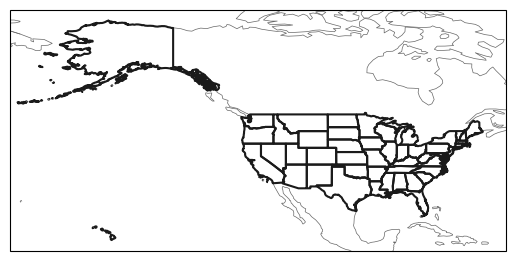

In [38]:
import xarray
import regionmask
import cartopy

# land_polygons = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_polygons = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50
land_polygons.plot(add_label=False)

In [ ]:
window_lons = np.linspace(min_lon, max_lon, num=3540)
window_lats = np.linspace(min_lat, max_lat, num = 1785)

pred_mask = land_polygons.mask(window_lons, window_lats).values

land_poly_2 = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
pred_mas2 = 
land_mask = ~np.isnan(pred_mask)


In [ ]:

selected = [0, 2, 5]  # region numbers
combined_mask = np.isin(mask, selected)

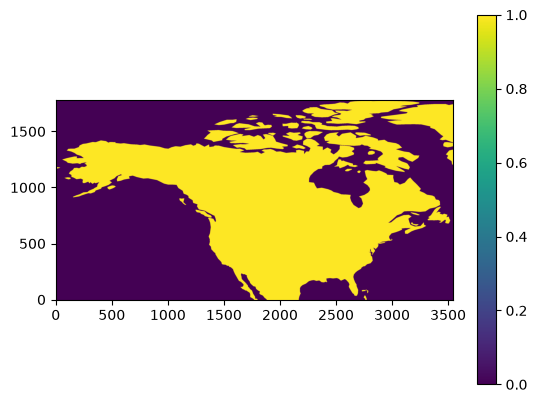

In [37]:
plt.imshow(land_mask, origin="lower")
plt.colorbar()

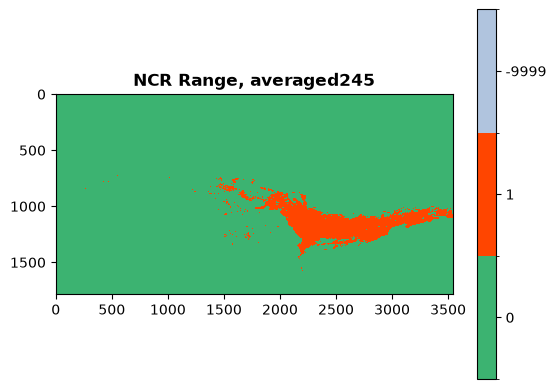

In [24]:
distr_rf_pred_245 = rasterio.open("outputs/prediction126_ensemble.tif").read(1)
plotit(distr_rf_pred_245, "NCR Range, averaged245", ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

In [25]:
distr_rf_pred_245 = rasterio.open("outputs/prediction245_ensemble.tif").read(1)
plotit(distr_rf_pred_245, "NCR Range, averaged245", ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

RasterioIOError: outputs/prediction245_ensemble.tif: No such file or directory

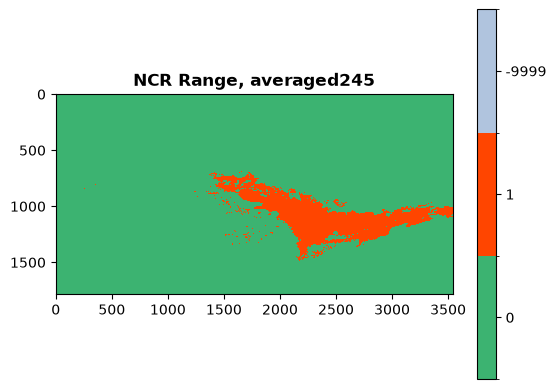

In [ ]:
distr_rf_pred_245 = rasterio.open("outputs/prediction370_ensemble.tif").read(1)
plotit(distr_rf_pred_245, "NCR Range, averaged245", ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

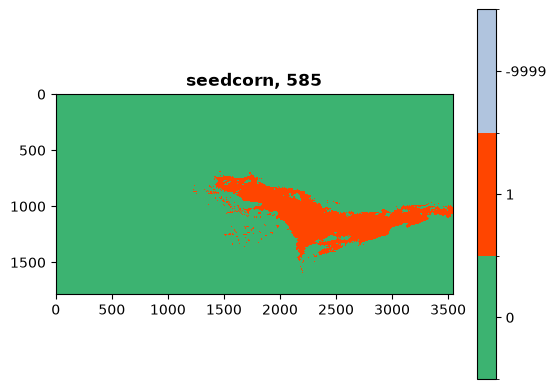

In [ ]:
distr_rf_pred_245 = rasterio.open("outputs/prediction585_ensemble.tif").read(1)
plotit(distr_rf_pred_245, command_ncr[3] + ', 585', ["mediumseagreen", "orangered", "lightsteelblue"], cmap="Greens")

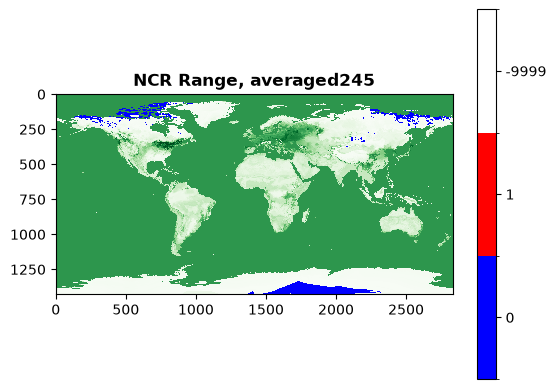

In [ ]:
distr_rf_245 = rasterio.open("outputs/rf1-images245/probability_1.0.tif").read(1)
plotit(distr_rf_245, "NCR Range, averaged245", ["blue", "red", "white"], cmap="Greens")



In [ ]:
distr

NameError: name 'distr' is not defined

In [ ]:
distr_rf_126 = rasterio.open("outputs/rf1-images126/probability_1.0.tif").read(1)
plotit(distr_rf_126, "NCR Range, averaged126", cmap="Greens")

In [ ]:
distr_rf_370 = rasterio.open("outputs/rf1-images370/probability_1.0.tif").read(1)
plotit(distr_rf_370, "NCR Range, averaged370", cmap="Greens")

In [ ]:
distr_rf_585 = rasterio.open("outputs/rf1-images585/probability_1.0.tif").read(1)
plotit(distr_rf_585, "NCR Range, averaged585", cmap="Greens")

In [ ]:
plotit(distr_rf_585[50:700, 100:1200], "smaller", cmap="Reds")

In [ ]:
plotit(distr_rf_126[50:700, 100:1200], "smaller", cmap="Reds")

In [ ]:
# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(future_ras_feats), ' raster features.')
print(future_ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6

In [ ]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

distr_rf = rasterio.open("outputs/rf1-images/probability_1.0.tif").read(1)
plotit(distr_rf, "NCR Range, averaged", cmap="Greens")